<h1><font color = 'Green'> <center>GIS Apps in Engineering: Assignment 4</h1>
<h3><font color = 'blue'> <center>Lajuk</h3>

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import geopandas as gpd
import charset_normalizer
import os
from matplotlib_map_utils.core.north_arrow import north_arrow

In [2]:
path = '/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-8'
os.chdir(path)

In [3]:
# Read the files
fname = 'WellMain.txt'
waterquality = 'WaterQualityMajor.txt'
boundfile = 'Liberty.gpkg'
res1 = charset_normalizer.from_path(fname).best()
res2 = charset_normalizer.from_path(waterquality).best()
print('WellMain.txt Encoding:', res1.encoding, 'and', 'Water Quality Encoding:', res2.encoding)

WellMain.txt Encoding: cp1250 and Water Quality Encoding: ascii


In [4]:
# WellMain.txt Encoding: {'cp1250'} and Water Quality Encoding: {'ascii'}

wells = pd.read_csv(fname, sep='|', encoding='cp1250', dtype='str')
wells.columns

Index(['StateWellNumber', 'County', 'RiverBasin', 'GMA', 'RWPA', 'GCD',
       'AquiferCode', 'AquiferCodeDescription', 'AquiferId', 'Aquifer',
       'Classification', 'AquiferPickMethod', 'LatitudeDD', 'Dlat', 'Mlat',
       'Slat', 'LongitudeDD', 'Dlong', 'Mlong', 'Slong', 'CoordinateSource',
       'Owner', 'Driller', 'WellDepth', 'DepthSource', 'LandSurfaceElevation',
       'LandSurfaceElevationMethod', 'DrillingStartDate', 'DrillingMonth',
       'DrillingDay', 'DrillingYear', 'DrillingEndDate', 'DrillingMethod',
       'BoreHoleCompletion', 'WellType', 'Pump', 'PowerType', 'WellUse',
       'WaterLevelStatus', 'CurrentWaterLevelWell', 'WaterQualityAvailable',
       'CurrentWaterQualityWell', 'ReportingAgency', 'OtherDataAvailable',
       'Remarks', 'WellReportTrackingNumber', 'PluggingReportTrackingNumber',
       'USGSSiteNumber', 'TCEQSourceId', 'GCDWellNumber', 'OwnerWellNumber',
       'OtherWellNumber', 'PreviousStateWellNumber', 'CreatedDate',
       'LastUpdateDate'],


In [5]:
wq = pd.read_csv(waterquality, sep='|', dtype='str')
wq.head()

,StateWellNumber,County,Aquifer,SampleMonth,SampleDay,SampleYear,SampleDate,SampleTime,SampleTimeZone,SampleNumber,...,SampleBU,SampleBUValue,ParameterCode,ParameterDescription,ParameterUnitOfMeasure,ParameterFlag,ParameterValue,ParameterValuePlusMinus,CreatedDate,LastUpdateDate
0,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,39086,ALKALINITY FIELD DISSOLVED AS CACO3,MG/L AS CACO3,NaN,186,NaN,NaN,NaN
1,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,00415,"ALKALINITY, PHENOLPHTHALEIN (MG/L)",mg/L,NaN,0,NaN,2016-04-28,NaN
2,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,00410,"ALKALINITY, TOTAL (MG/L AS CACO3)",MG/L AS CACO3,NaN,188,NaN,2016-04-28,NaN
3,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,01503,"ALPHA, DISSOLVED (PC/L)",PC/L,NaN,6.4000000000000004,2.6000000000000001,NaN,NaN
4,0148904,Dallam,Ogallala,9,18,1992,1992-09-18,1430,NaN,1,...,B,NaN,01000,"ARSENIC, DISSOLVED (UG/L AS AS)",ug/L,<,10,NaN,NaN,NaN


In [6]:
wq.columns

Index(['StateWellNumber', 'County', 'Aquifer', 'SampleMonth', 'SampleDay',
       'SampleYear', 'SampleDate', 'SampleTime', 'SampleTimeZone',
       'SampleNumber', 'Reliability', 'CollectionEntity', 'AnalyzedLab',
       'SampledAquifer', 'SampleTopInterval', 'SampleBottomInterval',
       'CollectionRemarks', 'SampleBU', 'SampleBUValue', 'ParameterCode',
       'ParameterDescription', 'ParameterUnitOfMeasure', 'ParameterFlag',
       'ParameterValue', 'ParameterValuePlusMinus', 'CreatedDate',
       'LastUpdateDate'],
      dtype='object')

In [7]:
ECLB = wq.loc[
    (wq['County'] == 'Liberty') & 
    (wq['ParameterCode'] == '00094'),
    ['StateWellNumber', 'ParameterCode', 'ParameterValue']
]
ECLB.head()

,StateWellNumber,ParameterCode,ParameterValue
1435411,6048101,00094,584
1435422,6048102,00094,566
1435440,6048103,00094,590
1435478,6048104,00094,717
1435513,6048106,00094,301


In [8]:
wellsLB = wells.loc[
    wells['County'] == 'Liberty',
    ['StateWellNumber', 'LatitudeDD', 'LongitudeDD', 'County']
]
wellsLB.head()    

,StateWellNumber,LatitudeDD,LongitudeDD,County
101151,6040901,30.3994450,-95.0019450,Liberty
101152,6040902,30.4016670,-95.0008340,Liberty
101153,6040903,30.3994450,-95.0047230,Liberty
101154,6040904,30.4016670,-95.0030560,Liberty
101562,6048101,30.3447220,-95.0850000,Liberty


In [9]:
#Merge these two tables
ECLB = ECLB.merge(wellsLB, on='StateWellNumber', how='inner')
ECLB.head()

,StateWellNumber,ParameterCode,ParameterValue,LatitudeDD,LongitudeDD,County
0,6048101,00094,584,30.3447220,-95.0850000,Liberty
1,6048102,00094,566,30.3447222,-95.0855556,Liberty
2,6048103,00094,590,30.3444450,-95.0850000,Liberty
3,6048104,00094,717,30.3480560,-95.0866670,Liberty
4,6048106,00094,301,30.3450000,-95.0875000,Liberty


In [10]:
ECLB = ECLB.rename(columns={'ParameterValue': 'EC'})
ECLB.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD,County
0,6048101,00094,584,30.3447220,-95.0850000,Liberty
1,6048102,00094,566,30.3447222,-95.0855556,Liberty
2,6048103,00094,590,30.3444450,-95.0850000,Liberty
3,6048104,00094,717,30.3480560,-95.0866670,Liberty
4,6048106,00094,301,30.3450000,-95.0875000,Liberty


In [11]:
# --- Aggregate by StateWellNumber to get mean ---
# Convert all columns to numeric; non-numeric become NaN
ECLB = ECLB.apply(pd.to_numeric, errors='coerce')

ECLBav = ECLB.groupby('StateWellNumber').mean().reset_index()
ECLBav.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD,County
0,6048101,94.0,584.0,30.344722,-95.085000,NaN
1,6048102,94.0,566.0,30.344722,-95.085556,NaN
2,6048103,94.0,590.0,30.344445,-95.085000,NaN
3,6048104,94.0,717.0,30.348056,-95.086667,NaN
4,6048106,94.0,301.0,30.345000,-95.087500,NaN


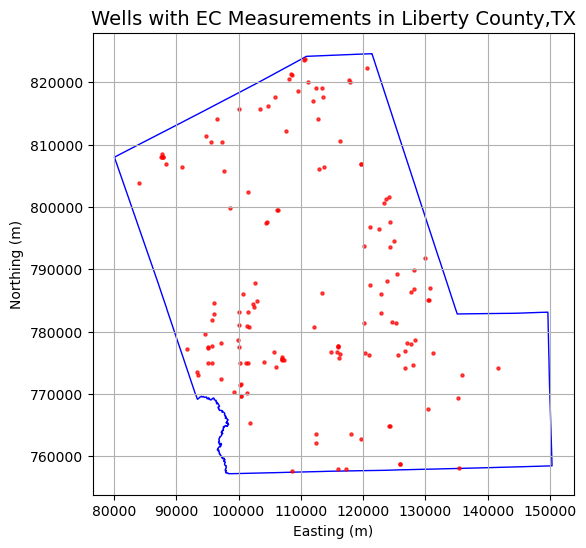

In [12]:
# --- Create a point GeoDataFrame ---
ECWGS = gpd.GeoDataFrame(
    ECLBav,
    geometry=gpd.points_from_xy(ECLBav['LongitudeDD'], ECLBav['LatitudeDD']),
    crs="EPSG:4326"  # WGS84 lat/lon
)

# Project both datasets to a common CRS (Albers Equal Area)
ECAEA = ECWGS.to_crs('EPSG:5070')

# --- Load and plot Liberty County boundary ---
LibAEA = gpd.read_file(boundfile)

# Reproject boundary to match well data
LibAEA = LibAEA.to_crs('EPSG:5070')

# --- Plot both together ---
fig, ax = plt.subplots(figsize=(8, 6))
LibAEA.plot(ax=ax, color='none', edgecolor='blue', linewidth=1, label='Liberty County')
ECAEA.plot(ax=ax, color='red', markersize=5, alpha=0.7, label='Wells')
ax.set_title("Wells with EC Measurements in Liberty County,TX", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.grid()
plt.show()

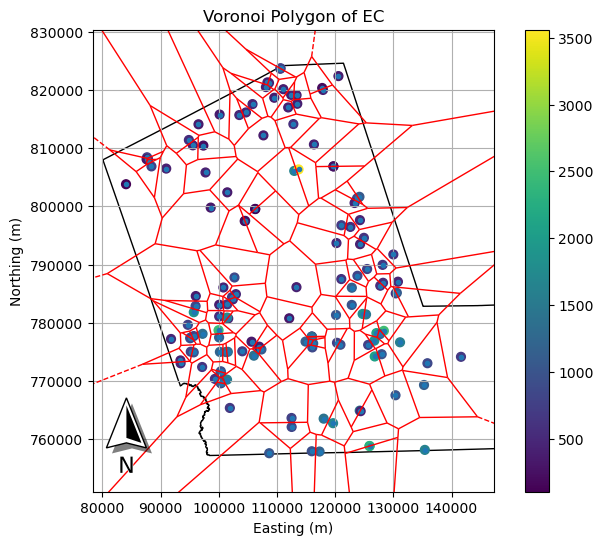

In [13]:
seedpts = np.column_stack((ECAEA.geometry.x, ECAEA.geometry.y))
vor = Voronoi(seedpts)

# Create figure and axes
fig, ax = plt.subplots(figsize=(8,6))

# Plot county boundary
LibAEA.plot(ax=ax, facecolor='none', edgecolor='black')

# Plot Voronoi diagram on same axes
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='red')

# Plot points
points_plot = ECAEA.plot(ax=ax, column='EC', cmap='viridis', legend=True, markersize=40)

# Add north arrow (matplotlib-map-utils style)
north_arrow(ax=ax, location="lower left", rotation={"crs": 4326, "reference": "center"}, scale=0.5)

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid()
plt.title("Voronoi Polygon of EC")
plt.show()


In [14]:
len(ECAEA)

147

In [15]:
# --- Export the LibAEA and ECAEA as gpkg files ---

# Path to the GeoPackage file
output_gpkg = "LIBEECAEA.gpkg"

# Save each layer with a unique layer name
LibAEA.to_file(output_gpkg, layer='County', driver='GPKG')
ECAEA.to_file(output_gpkg, layer='EC', driver='GPKG')

# --- Save as separate gpkg files ---
outEC = 'ECAEA.gpkg'
outCty = 'LibAEA.gpkg'
LibAEA.to_file(outCty, layer='County', driver='GPKG')
ECAEA.to_file(outEC, layer='EC_Wells', driver='GPKG')

print("✅ Files successfully saved:")
print(" -", output_gpkg, " (combined layers: County + EC_Wells)")
print(" -", outCty, " (Liberty County only)")
print(" -", outEC, " (EC Wells only)")


✅ Files successfully saved:
 - LIBEECAEA.gpkg  (combined layers: County + EC_Wells)
 - LibAEA.gpkg  (Liberty County only)
 - ECAEA.gpkg  (EC Wells only)
